In [ ]:
from sklearn.svm import SVC
from matplotlib.colors import ListedColormap

def plot_decision_boundary(X, y, clf):
    '''
    Función que grafica el híperplano separador, 'decision boundary' o frontera de un clasificador.
    X corresponde a los datos
    y corresponde a las etiquetas
    clf es el clasificador a evaluar
    '''
    resolution = 0.02
    markers = ("o", "^", "s", "v", "<")
    colors = ("red", "blue", "lightgreen", "gray", "cyan")

    cmap = ListedColormap(colors[:len(np.unique(y))])

    # Crear espacio de características que se va a clasificar para dibujar
    # la frontera/híperplano separador

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(
        np.arange(x1_min, x1_max, resolution),
        np.arange(x2_min, x2_max, resolution)
    )

    lab = clf.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)
    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
        y=X[y == cl, 1],
        alpha=0.8,
        c=colors[idx],
        marker=markers[idx],
        label=f'Class {cl}',
        edgecolor='black')
    return


# SVM: Consideraciones e implementación


## SVM lineal

Debido a que estamos hablando de un clasificador que trabaja directamente con los puntos de datos de forma más "geométrica" (distribución en el espacio de características o de entrada), es sensible ante las diferencias entre las escalas de nuestras columnas o atributos del dataset por lo tanto es importante normalizarlas

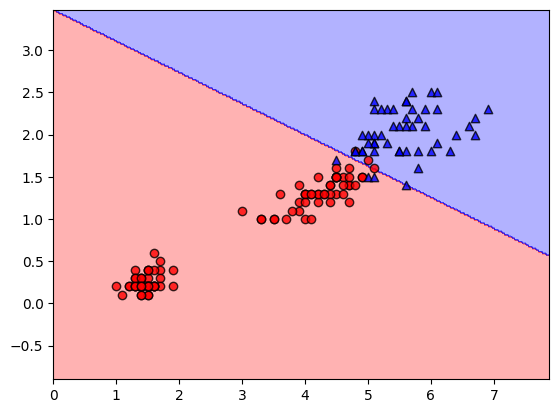

In [ ]:
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt
'''
Dataset consta de 3 tipos de planta (identificadas por 0, 1 y 2):
- Setosa
- Versicolor
- Virginica
Para cada planta se manejan las dimensiones (columnas):
- Longitud del sépalo
- Ancho del sépalo
- Longitud del pétalo
- Ancho del pétalo
'''
iris = datasets.load_iris()
X = iris["data"][:, (2, 3)] # longitud y ancho de pétalo
y = (iris["target"] == 2).astype(np.float64) # clasificador de planta "2" 0 o 1
'''
Se escalan las variables centrándolas en el 0 (media = 0) y desviación estándar 1.
Esto es muy importante en SVM porque se "equilibra" el peso/importancia de las características.
'''
svm_clf = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_lineal", SVC(kernel="linear", C=1))
])

svm_clf.fit(X, y)
plot_decision_boundary(X, y, svm_clf)

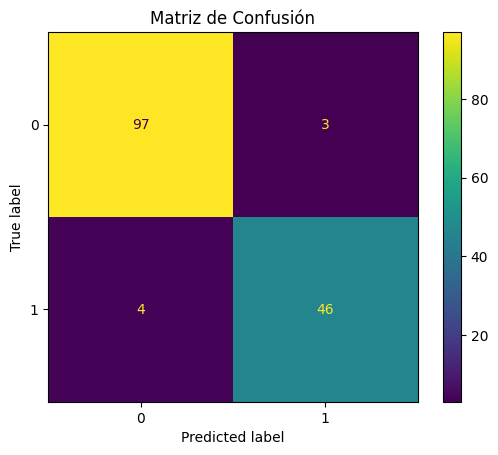

np.float64(0.9974000000000001)

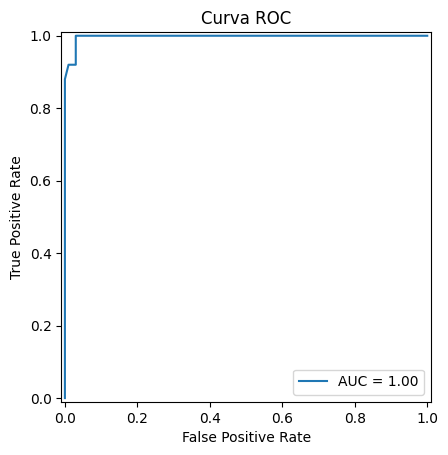

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, RocCurveDisplay, roc_auc_score
from sklearn.model_selection import train_test_split

y_pred = svm_clf.predict(X)
y_score = svm_clf.decision_function(X)  # Para curva ROC

#print(svm_clf.decision_function(X))

# Matriz de confusión
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión")
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y, y_score)
roc_auc = auc(fpr, tpr)
display(roc_auc)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title("Curva ROC")
plt.show()

## No linealidad

### Dataset XOR

Se basa en la operación binaria *exclusive or*, que tiene como salida verdadero sólo si una de las dos entradas es verdadera.

Normalmente se toma como ejemplo para mostra distribuciones de dos clases que no son linealmente separables, como AND y OR.

<center>


![](https://drive.google.com/uc?export=view&id=1f4Se51RAP7eaFXobHFJIRu9QCjwxy2iM)


</center>

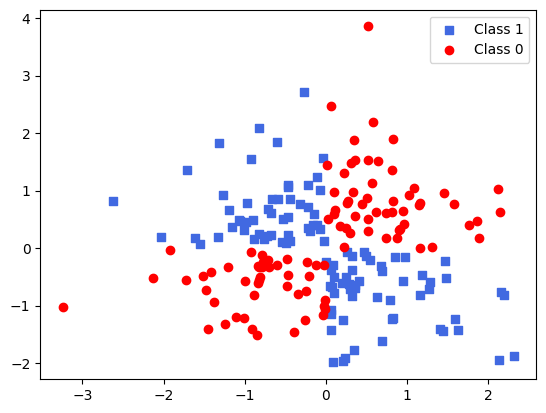

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
np.random.seed(42)

# Obtener una muestra de 200 filas aleatorias con 2 features (o columnas)
X_xor = np.random.randn(200, 2)

# Generar XOR dataset, donde la columna 1 y 2 son true o false
# y la columna objetivo, o la clase a predecir, es la función XOR sobre ellas
# y = xor(col1, col2)

y_xor = np.logical_xor(X_xor[:, 0] > 0, X_xor[:, 1] > 0)

# Reemplazar booleanos para graficar
y_xor = np.where(y_xor, 1, 0)

# True (0, 1) y (1, 0)
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1],
            c = "royalblue", marker="s",
            label="Class 1")

# False (0,0) y (1, 1)
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1],
            c = "red", marker="o",
            label="Class 0")
plt.legend()
plt.show()


## Utilizando el kernel trick para encontrar el hiperplano separador

### Kernel Gaussiano

Como se había hablado anteriormente, este kernel funciona ya que preserva las propiedades tras ser aplicado a un producto punto, que es la expresión que se encontraba en la función a minimizar.

$
\kappa(x_i, x_j) = e^{\big(\dfrac{-||x_i - x_j||^2}{2\sigma^2}\big)}
$

Que puede ser simplificado para tener sólo un hiperparámetro:

$\gamma = \dfrac{1}{2\sigma^2} \Longrightarrow e^{-\gamma||x_i - x_j||^2} $



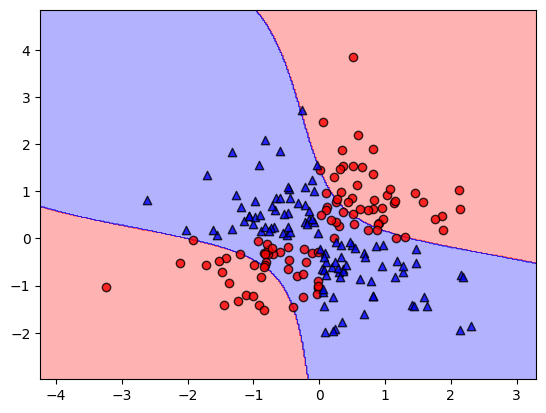

In [ ]:
svm_clf = SVC(kernel="rbf", C=1.0, gamma=0.1, random_state=42)
svm_clf.fit(X_xor, y_xor)
plot_decision_boundary(X_xor, y_xor, svm_clf)
plt.show()

### Búsqueda de Hiperparámetro (Costoso!)

In [ ]:
from sklearn.model_selection import GridSearchCV

# Cambiar el hiperparámetro gamma aumentándolo hace que la curva sea más delgada
# Mientras que si es más alto será más ancha
𝑥
# Al final, tanto C como gamma aportan al underfitting y overfitting

# Hiperparámetros que se desean buscar y su rango (compartido)
param_range = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
param_grid = [{
  'C': param_range,
  'gamma': param_range,
}]

gs = GridSearchCV(estimator=SVC(random_state=42),
  param_grid=param_grid,
  scoring='accuracy',
  cv=10,
  n_jobs=-1)

gs = gs.fit(X_xor, y_xor)

print(gs.best_score_)
print(gs.best_params_)

0.975
{'C': 1000.0, 'gamma': 0.1}


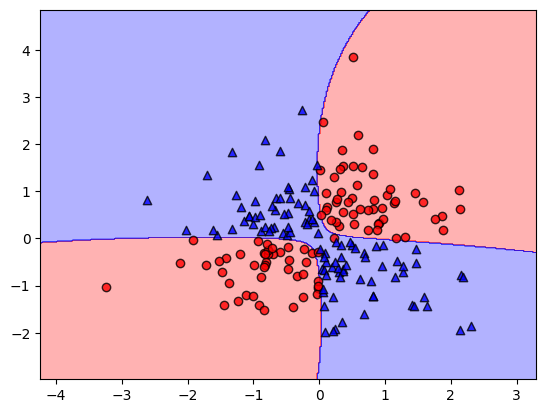

In [ ]:
svm_clf = SVC(kernel="rbf", C=1000.0, gamma=0.1, random_state=42)
svm_clf.fit(X_xor, y_xor)
plot_decision_boundary(X_xor, y_xor, svm_clf)
plt.show()

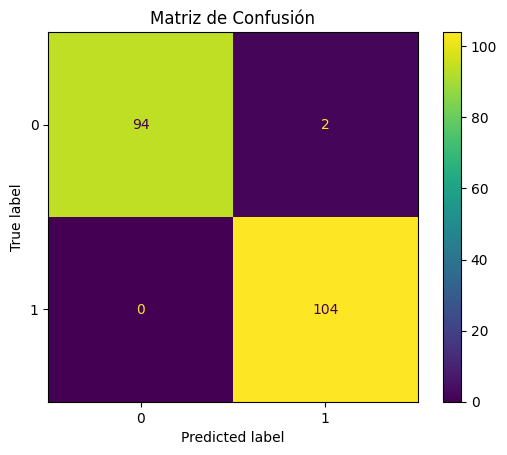

np.float64(0.9997996794871794)

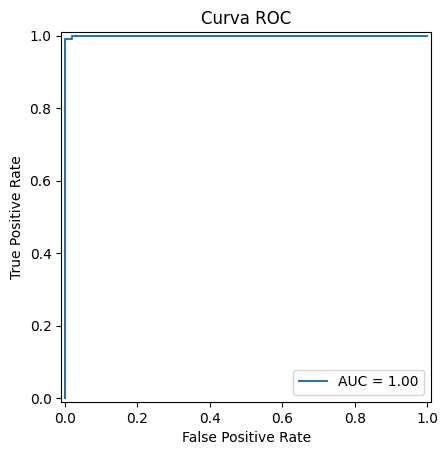

In [ ]:
y_xor_pred = svm_clf.predict(X_xor)
y_xor_score = svm_clf.decision_function(X_xor)

# Matriz de confusión
cm = confusion_matrix(y_xor, y_xor_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión")
plt.show()

# Curva ROC
fpr, tpr, thresholds = roc_curve(y_xor, y_xor_score)
roc_auc = auc(fpr, tpr)
display(roc_auc)

RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc).plot()
plt.title("Curva ROC")
plt.show()

## Resumen de SVM

**SVM (Support Vector Machine)**

*¿Para qué sirve?*<br>
> <div style="text-align: justify">
Permite encontrar el híperplano o frontera de decisión capaz de separar el espacio de características (mis datos) en dos clases (positivo, negativo). Esto se logra mediante la aplicaicón de multiplicadores de Lagrange y derivadas de primer orden, que terminan demostrando que el híperplano puede ser calculado mediante el producto punto de pares de muestras de mis datos! (cálculo simple y atractivo para problemas computacionales!).
  </div>

*¿Qué es un support vector?*
> <div style="text-align: justify">
Básicamente son los patrones de entrenamiento (datos) que habitan más cercanos a la frontera (híperplano separador de clases). Hay que pensarlos como los puntos más críticos de ambos conjuntos. Se les llama "support" ya que son utilizados para maximizar el margen entre clases (definición del híperplano separador). Para espacios linealmente separables, estos support vectors habitan en el espacio de entrada. Para datos que no son linealmente separables, estos deben ser representados en un *espacio de características*.
</div>

*¿Qué es un espacio de características? ¿Cómo se diferencia de un espacio de entrada?*

> - **Espacio de entrada**: Datos crudos. Son los datos originales que no han pasado por ninguna transformación. Pueden ser imágenes de entrada (binarias y de 2 dimensiones, a color de 3 canales, etc.), tabulares de k dimensiones (dependiendo del número de columnas), etc.
> - **Espacio de características**: Se toman los datos crudos y son transformados a un espacio de mayor dimensionalidad. La idea es que los vectores contengan las dimensiones que mejor representan a los datos originales para la tarea de aprendizaje. SVM logra esto mediante el *''Kernel trick''*.

*¿Cómo se transforman datos de entrada a un espacio de características?*
> <div style="text-align: justify">
Mediante el uso de *kernels*. Distintos kernels son básicamente funciones que mapean los datos de entrada a distintas dimensiones, permitiendo una mejor separación de las clases. De esta forma, el híperplano separador al que se llega en el espacio de entrada corresponde a una función no lineal determinada por el kernel escogido. La elección del kernel es una decisión arquitectónica (**Alerta de híperparámetro!**).
</div>

*Ok, todo lo que has mencionado hasta ahora ha sido para espacios de características completamente separables... ¿Qué pasa cuando hay presencia de ruido? Es decir, un dato outlier de la clase positiva dentro del clúster de la clase negativa (o visceversa).*
> <div style="text-align: justify">
Aquí es necesaria la introducción de un parámetro de regularización C tal que $0 < C \leq \infty$. En términos simples, este parámetro dicta qué tanto queremos evitar clasificar erróneamente cada muestra de mi espacio. Un C muy alto ($\infty$) es equivalente a la optimización de 'hard margin' o completamente intolerante a clasificaciones erróneas. Disminuir el hiperparámetro C conlleva a mayor flexibilidad en la clasificación.
</div>

La [implementación de SVM en scikit-learn (SVC)](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) contempla varios parámetros que pueden ser de interés, dependiendo del tipo de función utilizada en el kernel trick para encontrar el híperplano separador.

A continuación, dispongo de algunas fuentes útiles para entender cómo opera SVM:

1. [Video explicativo](https://www.youtube.com/watch?v=ny1iZ5A8ilA)
2. [Paper de Marti Hearst sobre presentación general de SVM y usos](https://www.zemris.fer.hr/predmeti/su/nastava/ag20022003/SVM-uvodni-clanak.pdf)
3. [Guía de Usuario de Scikit-Learn para SVM](https://scikit-learn.org/stable/modules/svm.html)

# Reducción de dimensionalidad

Una intuición al enfrentar problemas de aprendizaje consiste en pensar que mientras más información tenga disponible un modelo, mejores serán sus capacidades de aprendizaje e inferencia. De esta forma, podría parecer razonable asumir que describir los datos mediante una gran cantidad de características siempre es beneficioso, ya que el modelo dispondría de más información para distinguir patrones complejos. *¿O no?*

En la práctica ocurre un fenómeno conocido como la **maldición de la dimensionalidad**. A medida que aumenta la cantidad de dimensiones o características de un conjunto de datos, el espacio de representación crece de manera extremadamente rápida. Como consecuencia, los datos tienden a volverse dispersos y las muestras disponibles dejan de ser suficientes para cubrir adecuadamente dicho espacio. Las distancias entre muestras pierden capacidad discriminativa.

Esto puede introducir una serie de problemas:
- Los modelos requieren una cantidad significativamente mayor de datos para generalizar correctamente.
- Aumenta el riesgo de sobreajuste.
- El entrenamiento se vuelve computacionalmente más costoso.
- La presencia de características redundantes o irrelevantes pueden introducir ruido y degradar el desempeño del modelo.

Es así que surge la necesidad de contar con técnicas de reducción de dimensionalidad, permitiendo llegar a representaciones más compactas de los datos, conservando la mayor cantidad posible de información relevante.

## Principal Component Analysis (PCA)

Uno de los métodos más utilizados para este propósito es el Análisis de Componentes Principales o PCA. Esta corresponde a una técnica de reducción de dimensionalidad no supervisada que transforma un conjunto de variables posiblemente correlacionadas en un nuevo conjunto de variables llamadas componentes principales.

La idea central de PCA consiste en encontrar nuevas direcciones en el espacio de características donde los datos presentan la mayor variabilidad (**información!**) posible.

In [ ]:
#Importar datos
import kagglehub

path = kagglehub.dataset_download("uciml/red-wine-quality-cortez-et-al-2009")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'red-wine-quality-cortez-et-al-2009' dataset.
Path to dataset files: /kaggle/input/red-wine-quality-cortez-et-al-2009


In [ ]:
import pandas as pd

csv_path = path +'/winequality-red.csv'

wine_df = pd.read_csv(csv_path, sep=',', on_bad_lines='skip')
display(wine_df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


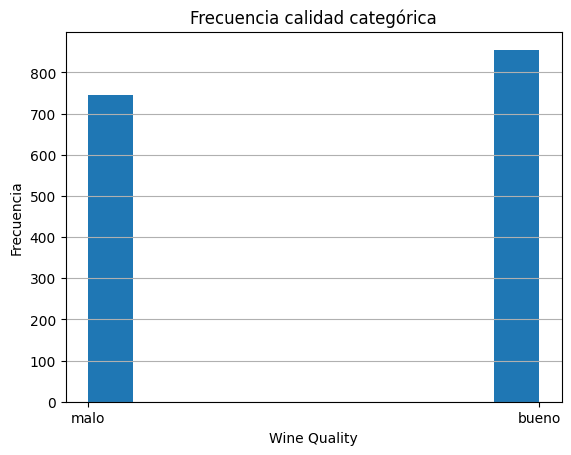

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   fixed acidity         1599 non-null   float64 
 1   volatile acidity      1599 non-null   float64 
 2   citric acid           1599 non-null   float64 
 3   residual sugar        1599 non-null   float64 
 4   chlorides             1599 non-null   float64 
 5   free sulfur dioxide   1599 non-null   float64 
 6   total sulfur dioxide  1599 non-null   float64 
 7   density               1599 non-null   float64 
 8   pH                    1599 non-null   float64 
 9   sulphates             1599 non-null   float64 
 10  alcohol               1599 non-null   float64 
 11  quality_categorical   1599 non-null   category
dtypes: category(1), float64(11)
memory usage: 139.2 KB


None

In [ ]:
# Adaptamos el dataset a un problema de clasificación binaria.
# Para esto utilizamos el método cut de pandas, para crear la
# variable quality_categorical, agrupada en bins en base a la
# variable quality (0, 5] y (5, 10]
#
# Decidimos que "Bueno" es la clase positiva.

wine_df['quality_categorical'] = pd.cut(
  wine_df['quality'],
  bins = [0, 5, 10],
  labels = ['malo', 'bueno'],
)

wine_df.drop('quality', axis=1, inplace=True)

wine_df['quality_categorical'].hist()
plt.title('Frecuencia calidad categórica')
plt.xlabel('Wine Quality')
plt.ylabel('Frecuencia')
plt.grid(axis='x')
plt.show()

# Dropeamos la variable quality, y ahora contamos con
# quality_categorical
display(wine_df.info())

In [ ]:
def divide_partition_set(df, target_column):
  y = df[target_column].copy()
  X = df.drop(target_column, axis=1)
  return X, y

train_ds, test_ds = train_test_split(
    wine_df,
    stratify = wine_df['quality_categorical'],
    test_size = 0.3,
    random_state=42)

train_x, train_y = divide_partition_set(train_ds, 'quality_categorical')
test_x, test_y = divide_partition_set(test_ds, 'quality_categorical')

In [ ]:
svm_wine = Pipeline([
    ("scaler", StandardScaler()),
    ("svm_lineal", SVC(C=1))
])

svm_wine.fit(train_x, train_y)

Pipeline(steps=[('scaler', StandardScaler()), ('svm_lineal', SVC(C=1))])

Accuracy SVM con dimensionalidad original: 0.78125


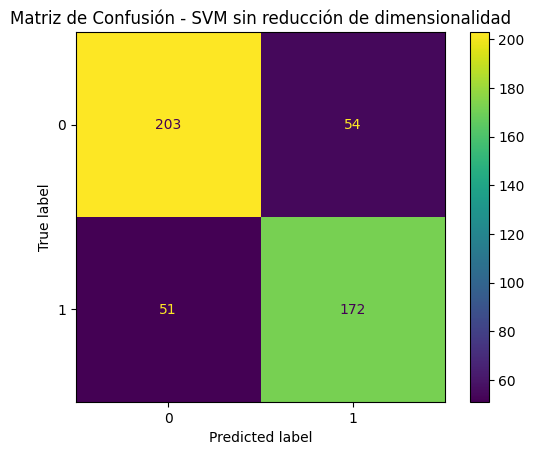

In [ ]:
from sklearn.metrics import accuracy_score

y_pred_wine = svm_wine.predict(test_x)

acc_wine = accuracy_score(test_y, y_pred_wine)

print("Accuracy SVM con dimensionalidad original:", acc_wine)

# Matriz de confusión
cm = confusion_matrix(test_y, y_pred_wine)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión - SVM sin reducción de dimensionalidad")
plt.show()

In [ ]:
# Ahora aplicamos PCA
from sklearn.decomposition import PCA

# Escalamiento previo a PCA
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train_x)
X_test_scaled = scaler.transform(test_x)

# Reducción de dimensionalidad
pca = PCA(n_components=2)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Dimensión original:", train_x.shape[1])
print("Dimensión reducida:", X_train_pca.shape[1])

Dimensión original: 11
Dimensión reducida: 2


Varianza explicada por componente:


array([0.28562252, 0.17436764])

Varianza explicada acumulada:


array([0.28562252, 0.45999016])

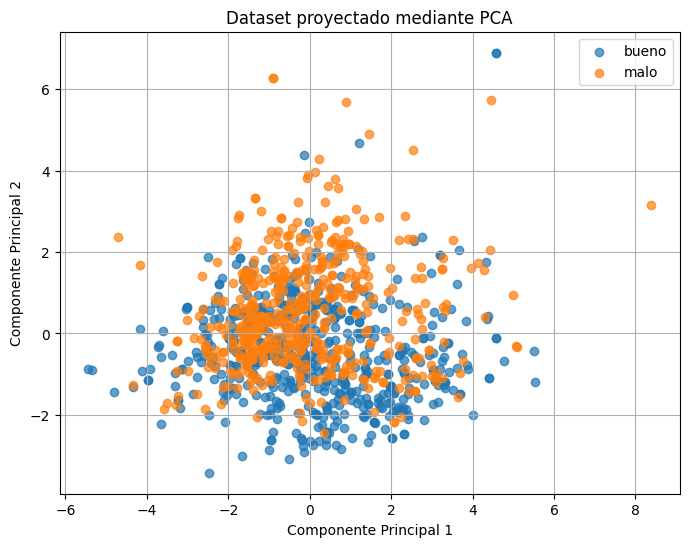

In [ ]:
# Cómo se ve la información retenida posterior a la reducción

print("Varianza explicada por componente:")
display(pca.explained_variance_ratio_)

print("Varianza explicada acumulada:")
display(np.cumsum(pca.explained_variance_ratio_))

# Visualización de componentes principales
plt.figure(figsize=(8, 6))

for label in np.unique(train_y):

    plt.scatter(
        X_train_pca[train_y == label, 0],
        X_train_pca[train_y == label, 1],
        label=label,
        alpha=0.7
    )

plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.title("Dataset proyectado mediante PCA")
plt.legend()
plt.grid()
plt.show()

Accuracy SVM con PCA: 0.65625


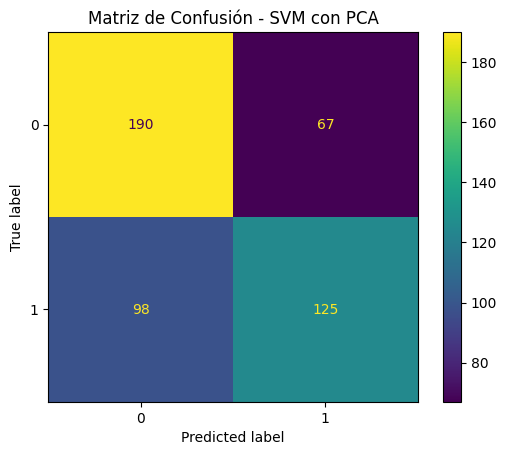

In [ ]:
svm_pca = SVC(C=1)

svm_pca.fit(X_train_pca, train_y)

y_pred_pca = svm_pca.predict(X_test_pca)

acc_pca = accuracy_score(test_y, y_pred_pca)

print("Accuracy SVM con PCA:", acc_pca)

# Matriz de confusión
cm = confusion_matrix(test_y, y_pred_pca)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Matriz de Confusión - SVM con PCA")
plt.show()


Fuente: [Guía de Usuario deScikit-Learn para PCA](https://scikit-learn.org/stable/modules/decomposition.html#pca)